<a href="https://colab.research.google.com/github/junseok-jay/AI_lab/blob/main/week11/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.8.0+cu126


In [15]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/uber-fares-dataset")
dest = "/content/uber-fares-dataset"

try:
  os.system(f"cp -r '{path}' '{dest}'")
  dest = dest + "/uber.csv"

  print("Path to dataset files:", path)
  print("destination to dataset files:", dest)
except:
  print("Error")


Using Colab cache for faster access to the 'uber-fares-dataset' dataset.
Path to dataset files: /kaggle/input/uber-fares-dataset
destination to dataset files: /content/uber-fares-dataset/uber.csv


In [16]:
def preprocess_uber(csv_path):
    df = pd.read_csv(csv_path)

    # 필요없는 컬럼 제거
    df = df.drop(["Unnamed: 0", "key"], errors="ignore", axis=1)

    # 컬럼명 변경
    df.columns = ['총금액','탑승시간','승차경도','승차위도','하차경도','하차위도','승객수']

    # 날짜 처리
    df['탑승시간'] = pd.to_datetime(df['탑승시간'])
    df['year'] = df['탑승시간'].dt.year
    df['month'] = df['탑승시간'].dt.month
    df['hour'] = df['탑승시간'].dt.hour
    df = df.drop("탑승시간", axis=1)

    # 거리 계산 (간단한 유클리드 거리)
    df["거리"] = (
        ((df['하차경도'] - df['승차경도'])**2 +
         (df['하차위도'] - df['승차위도'])**2) * 0.5
    )

    # 위치 컬럼 제거
    df = df.drop(['승차경도', '승차위도', '하차경도', '하차위도'], axis=1)

    # 이상치 제거
    df = df[(df['총금액'] > 0) & (df['총금액'] < 1000)]
    df = df[(df['승객수'] > 0) & (df['승객수'] <= 6)]
    df = df[df['거리'] < 5]

    # 결측치 제거
    df = df.dropna()

    return df

df = preprocess_uber(dest)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 198834 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   총금액     198834 non-null  float64
 1   승객수     198834 non-null  int64  
 2   year    198834 non-null  int32  
 3   month   198834 non-null  int32  
 4   hour    198834 non-null  int32  
 5   거리      198834 non-null  float64
dtypes: float64(2), int32(3), int64(1)
memory usage: 8.3 MB


In [17]:
print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {"Uber fares"}")
print(f"Target: fare (in $1s)")

# Display statistics
print(f"\nTarget statistics:")
print(f"  Min: ${y.min() * 1:.2f}")
print(f"  Max: ${y.max() * 1:.2f}")
print(f"  Mean: ${y.mean() * 1:.2f}")

Dataset Information:
Number of samples: 198834
Number of features: 5

Feature names: Uber fares
Target: fare (in $1s)

Target statistics:
  Min: $0.01
  Max: $499.00
  Mean: $11.36


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")

Training set size: 159067 samples
Test set size: 39767 samples

✓ Data normalized (mean=0, std=1)


In [19]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 64
Number of training batches: 2486
Number of test batches: 622


In [30]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer

    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (5)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cpu


In [21]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


In [22]:
# Training parameters
num_epochs = 100

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Forward pass: compute predictions
        predictions = model(X_batch)

        # 2. Compute loss
        loss = criterion(predictions, y_batch)

        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients

        # 4. Update weights
        optimizer.step()

        train_loss += loss.item()

    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/100] | Train Loss: 27.2888 | Test Loss: 22.8817
Epoch [20/100] | Train Loss: 26.9292 | Test Loss: 22.7932
Epoch [30/100] | Train Loss: 26.7511 | Test Loss: 23.6834
Epoch [40/100] | Train Loss: 26.5301 | Test Loss: 23.2889
Epoch [50/100] | Train Loss: 26.4726 | Test Loss: 22.5869
Epoch [60/100] | Train Loss: 26.4214 | Test Loss: 29.0264
Epoch [70/100] | Train Loss: 26.4204 | Test Loss: 22.6408
Epoch [80/100] | Train Loss: 26.4273 | Test Loss: 23.0270
Epoch [90/100] | Train Loss: 26.3443 | Test Loss: 22.6821
Epoch [100/100] | Train Loss: 26.4207 | Test Loss: 24.0427
------------------------------------------------------------
Training complete!


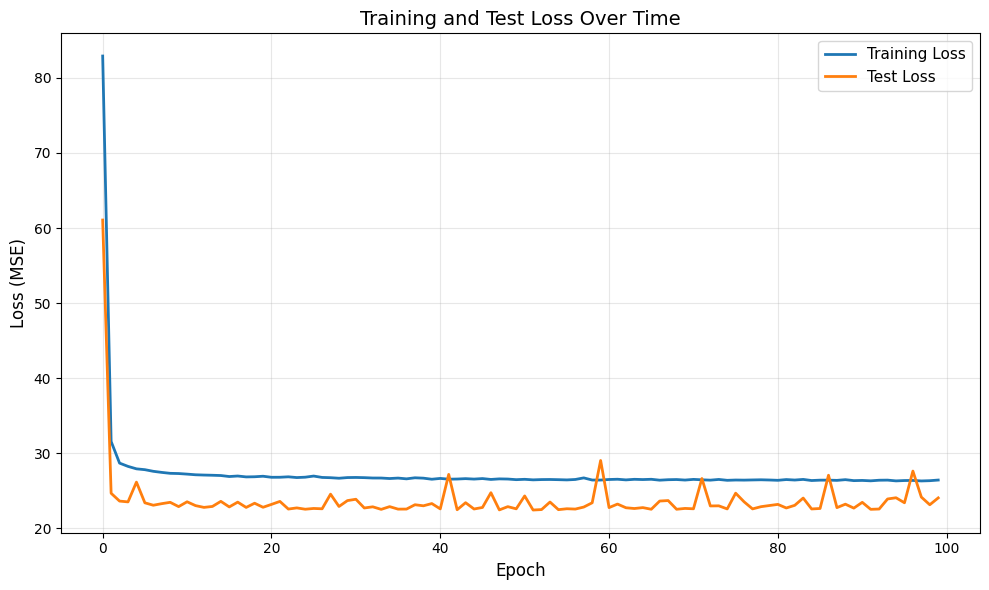

Final Training Loss: 26.4207
Final Test Loss: 24.0427


In [23]:

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [24]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"On average, predictions are off by ${mae * 100000:.2f}")
print(f"Model explains {r2*100:.2f}% of the variance in house prices")

Model Performance on Test Set:
Mean Squared Error (MSE):  24.0463
Root Mean Squared Error (RMSE): 4.9037
Mean Absolute Error (MAE): 2.1577
R² Score: 0.7436

Interpretation:
On average, predictions are off by $215771.96
Model explains 74.36% of the variance in house prices


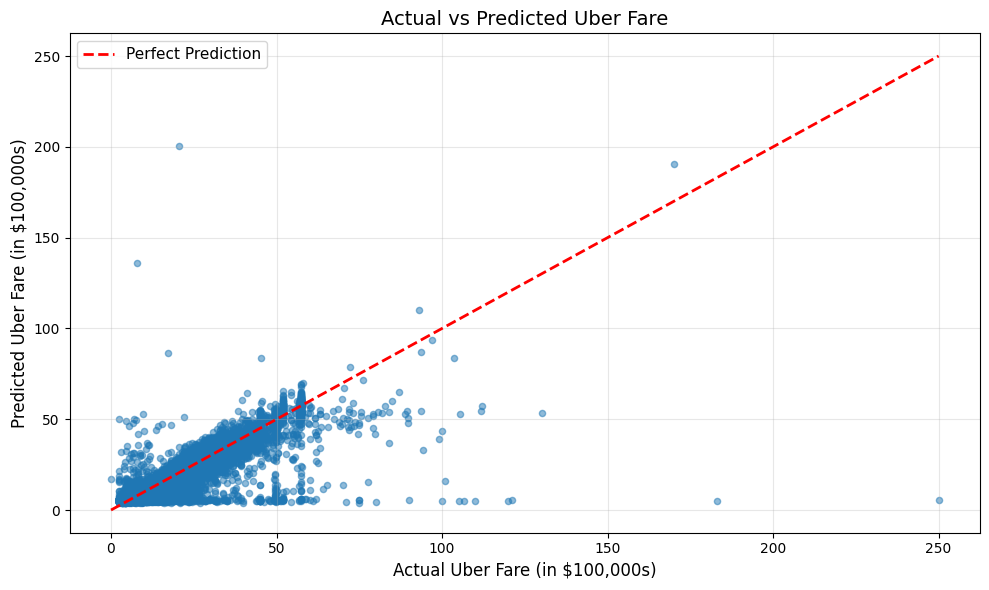


Sample Predictions (first 10 houses):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$   690,000 | $   864,447 | $  -174,447
$   650,000 | $   618,160 | $    31,840
$   600,000 | $   709,048 | $  -109,048
$ 3,210,000 | $ 3,361,441 | $  -151,441
$ 1,250,000 | $ 1,261,982 | $   -11,982
$   970,000 | $ 1,063,397 | $   -93,397
$   750,000 | $   606,562 | $   143,438
$   530,000 | $   658,756 | $  -128,756
$   930,000 | $   951,473 | $   -21,473
$ 1,500,000 | $ 1,594,868 | $   -94,868


In [28]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Uber Fare (in $100,000s)', fontsize=12)
plt.ylabel('Predicted Uber Fare (in $100,000s)', fontsize=12)
plt.title('Actual vs Predicted Uber Fare', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 Uber):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] * 100000
    predicted = y_pred[i][0] * 100000
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")

In [26]:
# Save model
torch.save(model.state_dict(), 'house_price_model.pth')
print("✓ Model saved to 'house_price_model.pth'")

# To load the model later:
# model = RegressionModel(input_size)
# model.load_state_dict(torch.load('house_price_model.pth'))
# model.to(device)
# model.eval()

print("\nTo load this model later, use:")
print("  model = RegressionModel(input_size)")
print("  model.load_state_dict(torch.load('house_price_model.pth'))")
print("  model.to(device)")
print("  model.eval()")

✓ Model saved to 'house_price_model.pth'

To load this model later, use:
  model = RegressionModel(input_size)
  model.load_state_dict(torch.load('house_price_model.pth'))
  model.to(device)
  model.eval()
